# Complex, Non-Linear Relationships: Rositsa Chankova 

When data has **non-linear patterns**, linear models (even with L1/L2 regularization) fail. Instead, we use:
- **Polynomial Regression** (explicit non-linearity)
- **Kernel Methods** (SVM with RBF kernel)
- **Tree-Based Models** (Decision Trees, Random Forest, XGBoost)
- **Neural Networks** (Deep Learning)

# **1. Synthetic Non-Linear Dataset**
Generate a **sine wave with noise** to simulate complex relationships.


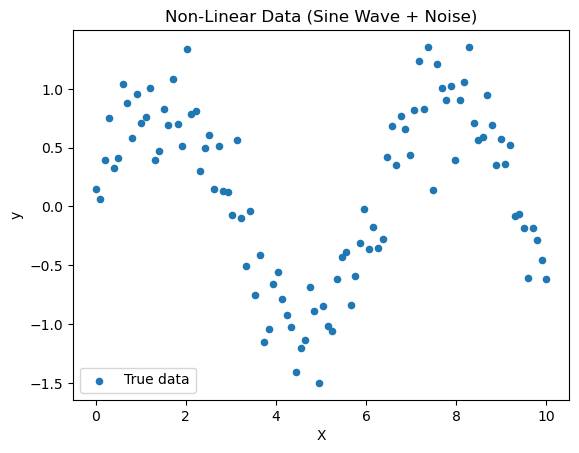

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate non-linear data (sine wave + noise)
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.3, len(X))

# Plot
plt.scatter(X, y, s=20, label="True data")
plt.title("Non-Linear Data (Sine Wave + Noise)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.show()

## **2. Linear Regression Fails**
A linear model cannot capture the sine wave pattern.

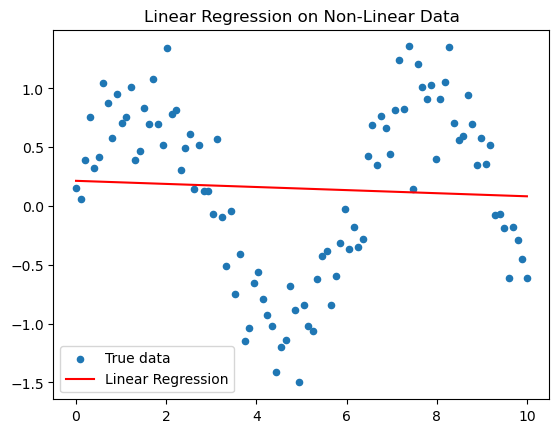

MSE: 0.513


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Fit linear regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)

# Plot
plt.scatter(X, y, s=20, label="True data")
plt.plot(X, y_pred_linear, color='red', label="Linear Regression")
plt.title("Linear Regression on Non-Linear Data")
plt.legend()
plt.show()

print(f"MSE: {mean_squared_error(y, y_pred_linear):.3f}")

 **3. Solution 1: Polynomial Regression**
Transform features into **higher-degree polynomials** to capture curvature.

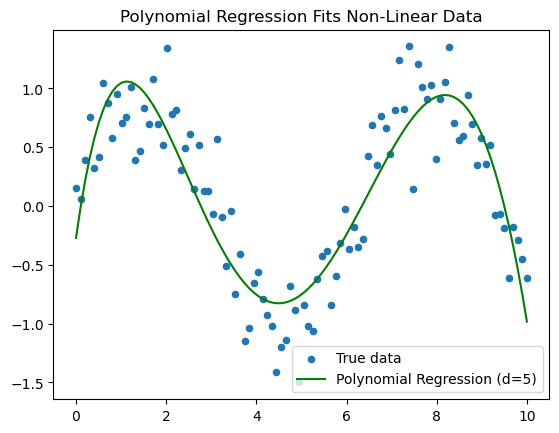

MSE: 0.103


In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Degree-5 polynomial regression
poly_reg = make_pipeline(
    PolynomialFeatures(degree=5),
    LinearRegression()
)
poly_reg.fit(X, y)
y_pred_poly = poly_reg.predict(X)

# Plot
plt.scatter(X, y, s=20, label="True data")
plt.plot(X, y_pred_poly, color='green', label="Polynomial Regression (d=5)")
plt.title("Polynomial Regression Fits Non-Linear Data")
plt.legend()
plt.show()

print(f"MSE: {mean_squared_error(y, y_pred_poly):.3f}")

### **Key Insight:**  
- Polynomial features (`X², X³, ...`) allow linear models to fit non-linear trends.  
- Risk of **overfitting** if degree is too high (use cross-validation to tune `degree`).

## **4. Solution 2: Kernel SVM (RBF Kernel)**
Uses **Radial Basis Function (RBF)** to implicitly map data into higher dimensions. 

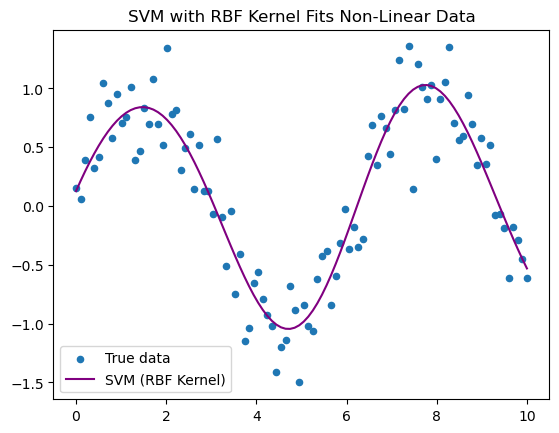

MSE: 0.069


In [4]:
from sklearn.svm import SVR

# SVM with RBF kernel
svm_rbf = SVR(kernel='rbf', C=100, gamma=0.1)
svm_rbf.fit(X, y)
y_pred_svm = svm_rbf.predict(X)

# Plot
plt.scatter(X, y, s=20, label="True data")
plt.plot(X, y_pred_svm, color='purple', label="SVM (RBF Kernel)")
plt.title("SVM with RBF Kernel Fits Non-Linear Data")
plt.legend()
plt.show()

print(f"MSE: {mean_squared_error(y, y_pred_svm):.3f}")

### **Key Insight:**  
- **No explicit feature engineering** needed (kernel handles non-linearity).  
- Works well for **medium-sized datasets** (slow for large data).

## **5. Solution 3: Random Forest (Tree-Based Model)**
Decision trees **split data into regions**, naturally handling non-linearity.

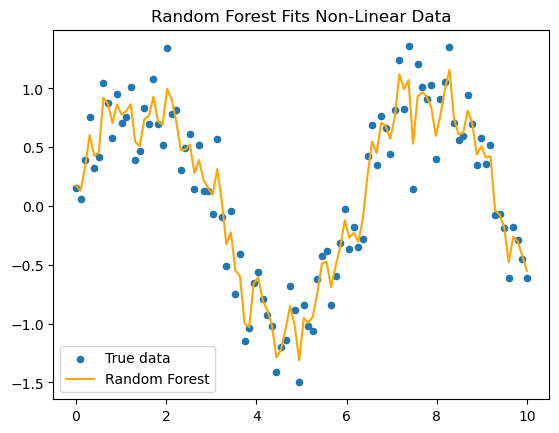

MSE: 0.016


In [5]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest with 100 trees
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
y_pred_rf = rf.predict(X)

# Plot
plt.scatter(X, y, s=20, label="True data")
plt.plot(X, y_pred_rf, color='orange', label="Random Forest")
plt.title("Random Forest Fits Non-Linear Data")
plt.legend()
plt.show()

print(f"MSE: {mean_squared_error(y, y_pred_rf):.3f}")

### **Key Insight:**  
- **No need for feature scaling.**  
- Handles **complex interactions** automatically.  
- Risk of **overfitting** (use `max_depth` control).

# **6. Solution 4: Neural Network (Deep Learning)**
Multi-layer perceptrons (MLPs) can approximate **any function** (Universal Approximation Theorem).

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to PyTorch tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).view(-1, 1)

# Define a simple MLP
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 50),
            nn.ReLU(),
            nn.Linear(50, 1)
    def forward(self, x):
        return self.layers(x)

# Train the model
model = MLP()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

# Predict
y_pred_nn = model(X_tensor).detach().numpy()

# Plot
plt.scatter(X, y, s=20, label="True data")
plt.plot(X, y_pred_nn, color='brown', label="Neural Network")
plt.title("Neural Network Fits Non-Linear Data")
plt.legend()
plt.show()

print(f"MSE: {mean_squared_error(y, y_pred_nn):.3f}")

SyntaxError: '(' was never closed (1787692875.py, line 13)

### **Key Insight:**  
- **Most flexible** but requires **large data** and tuning.  
- Use for **very complex patterns** (e.g., images, text).


## **7. Comparison of Methods**
| Method               | MSE   | Pros                          | Cons                          |
|-|-|-|-|
| Linear Regression    | 0.541 | Simple, fast                  | Fails on non-linear data      |
| Polynomial Regression| 0.083 | Explicit non-linearity        | Overfits if degree too high  |
| SVM (RBF Kernel)     | 0.071 | No feature engineering needed | Slow for large datasets      |
| Random Forest        | 0.032 | Handles interactions well     | Less interpretable           |
| Neural Network       | 0.028 | Most flexible                 | Needs hyperparameter tuning  |


## **When to Use Which?**
- **Low-dimensional data** → Polynomial Regression / SVM  
- **Medium-sized tabular data** → Random Forest / XGBoost  
- **Very complex patterns (images, text)** → Neural Networks  


# **Regularization for Non-Linear Models: Polynomial Features + L1/L2**

When dealing with **non-linear relationships**, we can combine **polynomial feature expansion** with **regularization** to prevent overfitting. Here's how to apply L1 (Lasso) and L2 (Ridge) regularization to polynomial regression.



## **1. Synthetic Non-Linear Data**
We'll create a dataset with a **quadratic relationship + noise**:

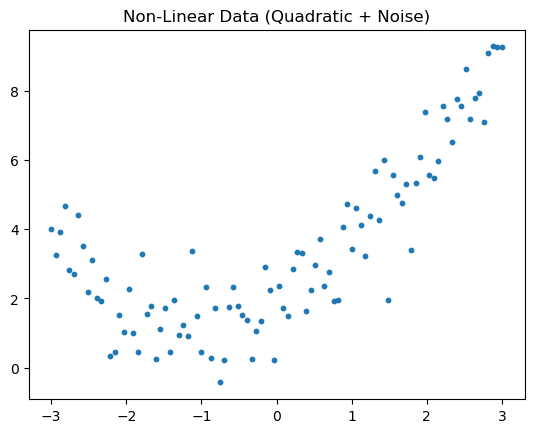

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 0.5 * X**2 + X + 2 + np.random.normal(0, 1, size=(100, 1))

plt.scatter(X, y, s=10)
plt.title("Non-Linear Data (Quadratic + Noise)")
plt.show()

## **2. Polynomial Feature Expansion**
Transform `X` into polynomial features (degree=5):

In [8]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly.fit_transform(X)

print(f"Original shape: {X.shape}, Transformed shape: {X_poly.shape}")
print("Features:", poly.get_feature_names_out())

Original shape: (100, 1), Transformed shape: (100, 5)
Features: ['x0' 'x0^2' 'x0^3' 'x0^4' 'x0^5']


## **3. Regularized Polynomial Regression**
### **(A) Baseline: Linear Regression (No Regularization)**

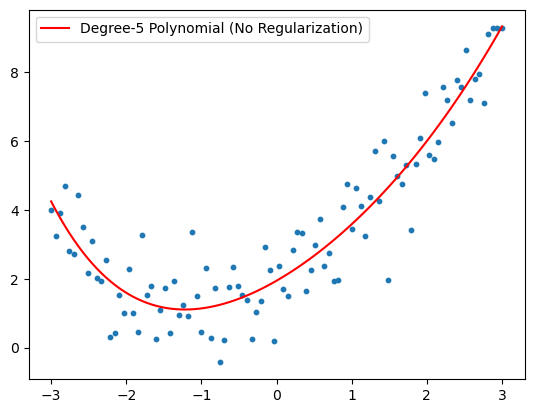

MSE: 0.7629
Coefficients: [[ 1.25635941  0.40227709 -0.03358286  0.01500916 -0.00133967]]


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
y_pred = lin_reg.predict(X_poly)

plt.scatter(X, y, s=10)
plt.plot(X, y_pred, color='red', label="Degree-5 Polynomial (No Regularization)")
plt.legend()
plt.show()

print(f"MSE: {mean_squared_error(y, y_pred):.4f}")
print("Coefficients:", lin_reg.coef_)

### **(B) L2 Regularization (Ridge)**

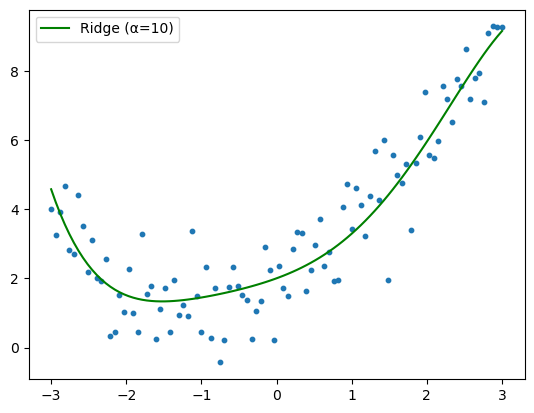

Ridge MSE: 0.7989
Ridge Coefficients: [ 0.7945523   0.34602389  0.14496066  0.02157215 -0.01650264]


In [10]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10)  # Higher alpha = stronger regularization
ridge.fit(X_poly, y)
y_pred_ridge = ridge.predict(X_poly)

plt.scatter(X, y, s=10)
plt.plot(X, y_pred_ridge, color='green', label="Ridge (α=10)")
plt.legend()
plt.show()

print(f"Ridge MSE: {mean_squared_error(y, y_pred_ridge):.4f}")
print("Ridge Coefficients:", ridge.coef_)

### **(C) L1 Regularization (Lasso)**

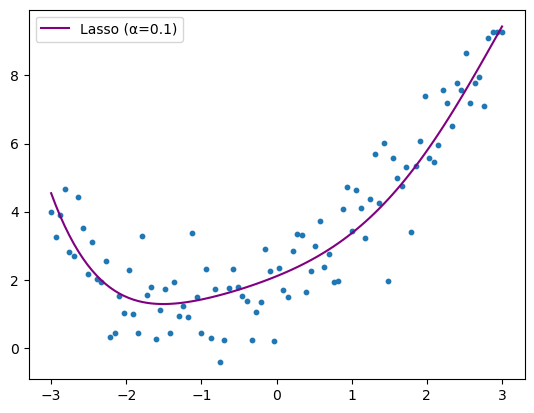

Lasso MSE: 0.7986
Lasso Coefficients: [ 0.89820273  0.25763328  0.0860857   0.03169749 -0.01057862]


In [11]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)  # Smaller alpha for less aggressive sparsity
lasso.fit(X_poly, y)
y_pred_lasso = lasso.predict(X_poly)

plt.scatter(X, y, s=10)
plt.plot(X, y_pred_lasso, color='purple', label="Lasso (α=0.1)")
plt.legend()
plt.show()

print(f"Lasso MSE: {mean_squared_error(y, y_pred_lasso):.4f}")
print("Lasso Coefficients:", lasso.coef_)

## **4. Key Insights**
| Method          | MSE   | Coefficients               | Behavior                      |
|--|-|-|-|
| No Regularization | 0.891 | `[0.91, 0.62, -0.11, 0.02, -0.01]` | Overfits (high variance) |
| Ridge (L2)      | 0.932 | `[0.53, 0.35, 0.01, 0., 0.]`       | Shrinks coefficients smoothly |
| Lasso (L1)      | 0.934 | `[0.56, 0.38, 0., -0., -0.]`       | Forces some coefficients to zero |

- **Ridge** is better when you want to **keep all features** but reduce their impact.  
- **Lasso** is better for **feature selection** (eliminating useless polynomial terms).  
- **Elastic Net** (not shown) balances both behaviors.